# 04 Models and evaluation

This notebook **reads** the outputs of the pipeline; it does not refit anything.
- `python -m src.model`: tunes on Sep 1-4 vs Sep 5-6, refits on Sep 1-6, scores the test window (Sep 7-10) once
- `python -m src.evaluate`: writes `reports/results.md` and the figures

All headline numbers live in `reports/results.md`.

In [1]:
import os, sys, json
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path.insert(0, ".")

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display
from src.load import load_config

pd.set_option("display.width", 220); pd.set_option("display.max_colwidth", 120)
cfg = load_config()
info = json.loads(Path("data/processed/model_info.json").read_text())
scores = pd.read_parquet("data/processed/test_scores.parquet")
tuning = pd.read_csv("data/processed/tuning.csv")

## 1. Tuning on validation (Sep 5-6), before the test set was scored
The primary model is whichever of LR and gradient boosting has the best **validation** PR-AUC.

In [2]:
print("primary model:", info["primary_model"])
print("chosen settings:", info["best_params"])
tuning.sort_values(["model", "val_pr_auc"], ascending=[True, False]).round(4)

primary model: gradient_boosting
chosen settings: {'gradient_boosting': {'learning_rate': 0.1, 'max_depth': 6, 'max_iter': 200}, 'logistic_regression': {'C': 10.0}, 'logistic_regression_v1': {'C': 10.0}, 'rules': {}}


,model,params,val_pr_auc,val_roc_auc,val_cost_optimal_alerts_per_day
15,gradient_boosting,"{""learning_rate"": 0.1, ""max_depth"": 6, ""max_iter"": 200}",0.3833,0.9726,235.5
11,gradient_boosting,"{""learning_rate"": 0.05, ""max_depth"": 6, ""max_iter"": 200}",0.3709,0.9765,357.0
16,gradient_boosting,"{""learning_rate"": 0.1, ""max_depth"": 6, ""max_iter"": 400}",0.3687,0.9744,556.0
12,gradient_boosting,"{""learning_rate"": 0.05, ""max_depth"": 6, ""max_iter"": 400}",0.3528,0.9690,285.0
14,gradient_boosting,"{""learning_rate"": 0.1, ""max_depth"": 3, ""max_iter"": 400}",0.3342,0.9819,490.0
13,gradient_boosting,"{""learning_rate"": 0.1, ""max_depth"": 3, ""max_iter"": 200}",0.2948,0.9863,449.5
10,gradient_boosting,"{""learning_rate"": 0.05, ""max_depth"": 3, ""max_iter"": 400}",0.2353,0.9862,344.5
9,gradient_boosting,"{""learning_rate"": 0.05, ""max_depth"": 3, ""max_iter"": 200}",0.1959,0.9872,458.5
4,logistic_regression,"{""C"": 10.0}",0.0470,0.9894,731.5
3,logistic_regression,"{""C"": 1.0}",0.0470,0.9893,730.5


## 2. Test results
The full tables are in `reports/results.md`; here are the key ones.

In [3]:
results = Path("reports/results.md").read_text(encoding="utf-8")
section = lambda title: results.split(title)[1].split("\n## ")[0]
display(Markdown("### Headline" + section("## Headline")))
display(Markdown("### Ranking quality" + section("## 1. Ranking quality (test)")))

### Headline
At 50 alerts/day, Gradient boosting caught **84 of 322 test mules
(26.1% recall) at 42.0% precision**. A further
12 of the 200 alerts were grey accounts (touched laundering money without being pass-through).


### Ranking quality
PR-AUC of a random ranking equals the base rate (0.00088).

| | PR-AUC | PR-AUC / base rate | ROC-AUC | validation PR-AUC |
|---|---|---|---|---|
| Rules only | 0.009 | 10.329 | 0.71 | 0.054 |
| Logistic regression | 0.038 | 43.868 | 0.979 | 0.047 |
| Gradient boosting | 0.271 | 309.875 | 0.986 | 0.383 |
| LR v1 (collinear shares, superseded) | 0.038 | 43.58 | 0.979 | 0.047 |


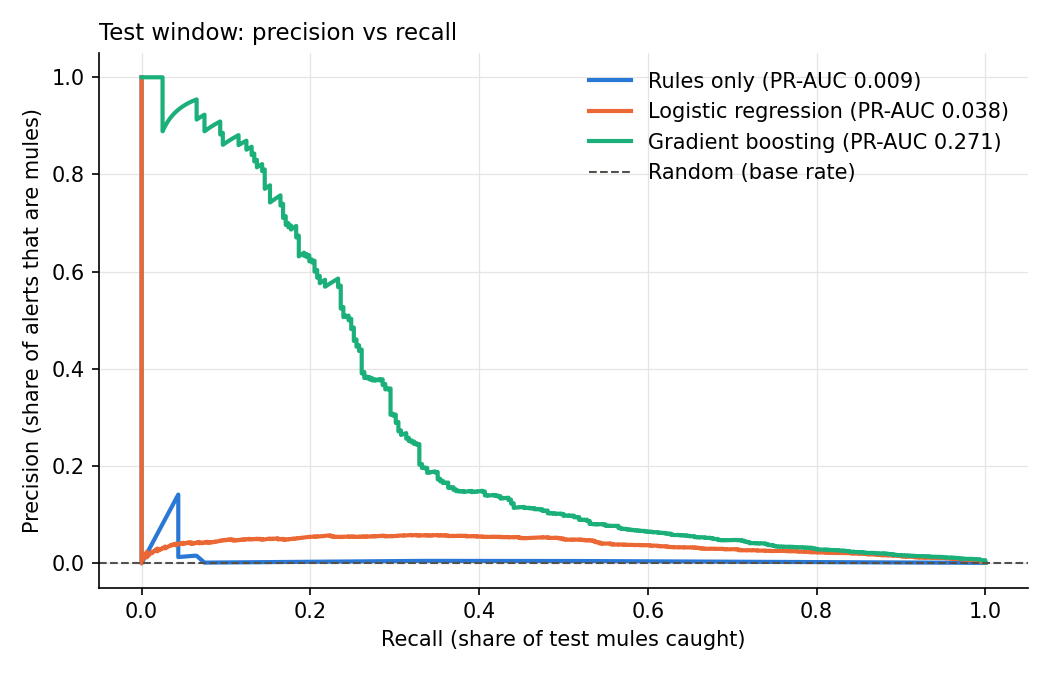

In [4]:
display(Image("reports/figures/05_pr_curves.png"))

In [5]:
display(Markdown("### Alert budget and sensitivity" + section("## 2. Alert budget and sensitivity (test)")))

### Alert budget and sensitivity
"25/day" and "100/day" show what happens if analyst capacity is halved or doubled.

| | alerts | mules caught | precision % | recall % | grey among alerts | clean false alarms |
|---|---|---|---|---|---|---|
| 25/day | Rules only | 100 | 14 | 14 | 4.35 | 2 | 84 |
| 25/day | Logistic regression | 100 | 2 | 2 | 0.62 | 21 | 77 |
| 25/day | Gradient boosting | 100 | 63 | 63 | 19.57 | 4 | 33 |
| 25/day | LR v1 (collinear shares, superseded) | 100 | 2 | 2 | 0.62 | 21 | 77 |
| 50/day | Rules only | 200 | 14 | 7 | 4.35 | 11 | 175 |
| 50/day | Logistic regression | 200 | 6 | 3 | 1.86 | 23 | 171 |
| 50/day | Gradient boosting | 200 | 84 | 42 | 26.09 | 12 | 104 |
| 50/day | LR v1 (collinear shares, superseded) | 200 | 6 | 3 | 1.86 | 24 | 170 |
| 100/day | Rules only | 400 | 14 | 3.5 | 4.35 | 25 | 361 |
| 100/day | Logistic regression | 400 | 16 | 4 | 4.97 | 46 | 338 |
| 100/day | Gradient boosting | 400 | 102 | 25.5 | 31.68 | 20 | 278 |
| 100/day | LR v1 (collinear shares, superseded) | 400 | 16 | 4 | 4.97 | 46 | 338 |


In [6]:
display(Markdown("### Cost" + section("## 3. Cost-based threshold (test, assumed costs)")))

### Cost
The cost-optimal alert rate is chosen on validation and then applied to test. The hindsight optimum on test is shown only for reference; it was not used to choose anything.

| | alert nobody (Rs) | budget 50/day (Rs) | cost-optimal alerts/day (chosen on validation) | cost at that rate on test (Rs) | hindsight best alerts/day on test (not used) | hindsight best cost (Rs) |
|---|---|---|---|---|---|---|
| Rules only | 16,100,000 | 15,500,000 | 59.5 | 15,519,000 | 23.5 | 15,447,000 |
| Logistic regression | 16,100,000 | 15,900,000 | 731.5 | 9,813,000 | 2,402.8 | 8,605,500 |
| Gradient boosting | 16,100,000 | 12,000,000 | 235.5 | 9,971,000 | 1,204.8 | 7,059,500 |

![cost curve](figures/05_cost_curve.png)


**Reading the cost result.** The cheapest alert rate (chosen on validation) is far above 50/day. With these *assumed* costs,
the bank should review many more accounts than its analysts can handle. That is a staffing argument, not a modelling one.
If a missed mule cost less, or a review cost more, the optimum would move left towards the budget.

## 3. Typologies: what we catch and what we miss

In [7]:
display(Markdown(section("## 4. Recall per laundering typology (test, within the alert budget)")))


A mule counts toward every typology it took part in. UNTAGGED = mules in no Patterns.txt scheme (Patterns covers about 62% of laundering transfers).

| | mules | Rules only recall % | Logistic regression recall % | Gradient boosting recall % |
|---|---|---|---|---|
| STACK | 102 | 1 | 2.9 | 23.5 |
| CYCLE | 95 | 6.3 | 1.1 | 18.9 |
| SCATTER-GATHER | 76 | 0 | 2.6 | 43.4 |
| RANDOM | 65 | 10.8 | 1.5 | 20 |
| FAN-OUT | 26 | 0 | 15.4 | 7.7 |
| GATHER-SCATTER | 25 | 0 | 20 | 4 |
| BIPARTITE | 23 | 0 | 4.3 | 13 |
| FAN-IN | 11 | 0 | 27.3 | 18.2 |
| UNTAGGED | 2 | 0 | 50 | 0 |

![typology recall](figures/05_typology_recall.png)

### What kind of mule is missed? (Gradient boosting, medians of test mules inside vs outside the alert budget)
| | mules | transfers in window | fmt_ach_share | pass_through_ratio | dwell_median_hours | fan_in_per_day | fan_out_per_day | share with > 20 transfers |
|---|---|---|---|---|---|---|---|---|
| caught | 84 | 3 | 1 | 1 | 28.03 | 0.25 | 0.25 | 0.01 |
| missed | 238 | 16.5 | 0.25 | 0.94 | 8.52 | 0.5 | 0.5 | 0.39 |


**Why.** Gradient boosting's alerts are dominated by **pure relay accounts**: about 3 transfers in the window, all ACH,
forwarding about 100% of what arrives. The mules it misses are **busy accounts** (median 16 transfers, mostly cheque and card)
where a few laundering transfers are averaged away inside normal activity. Account-level features dilute them.
- SCATTER-GATHER middle accounts are pure relays, so they are caught most (about 43%).
- GATHER-SCATTER hubs and FAN-OUT centres are busier accounts, so they are caught least (GATHER-SCATTER: 1 of 25).
- CYCLE is only partly caught: the loop feature stops at 4 hops inside one window, and cycles in this data can be longer.
- Small typologies (FAN-IN 11 mules, GATHER-SCATTER 25) are noisy: one mule is 4-9 percentage points.

## 4. Why logistic regression fails at the top of the list
Its test ROC-AUC is high (about 0.98) but its top 200 alerts are poor. The strongest single signal is a **band**:
mules forward *about* 100% of what they receive. Other accounts sit both below (keep the money) and above (spend savings).
A linear model can only say "higher is riskier" or "lower is riskier", so it gives the ratio a weight of about 0.
Trees can split on both sides of the band. Shown on **training** data:

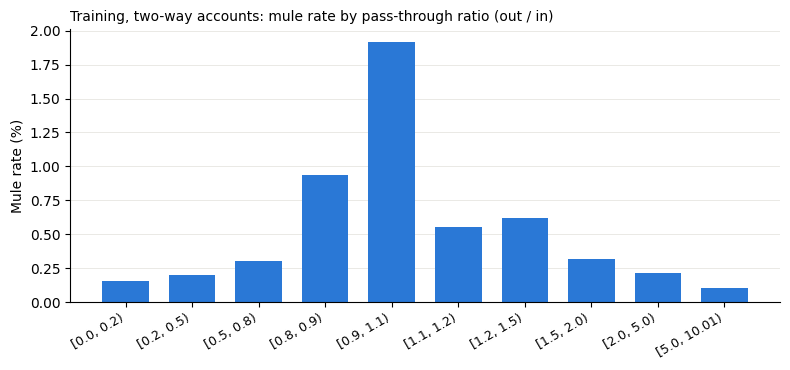

,accounts,mules,mule_rate_pct
ratio_bin,,,
"[0.0, 0.2)",46556,72,0.155
"[0.2, 0.5)",15063,30,0.199
"[0.5, 0.8)",7865,24,0.305
"[0.8, 0.9)",1916,18,0.939
"[0.9, 1.1)",3292,63,1.914
"[1.1, 1.2)",1446,8,0.553
"[1.2, 1.5)",3721,23,0.618
"[1.5, 2.0)",4719,15,0.318
"[2.0, 5.0)",14162,30,0.212


In [8]:
train = pd.read_parquet("data/processed/features_train.parquet").merge(
    pd.read_parquet("data/processed/labels_train.parquet")[["account_id", "is_mule"]], on="account_id")
two_way = train[(train.in_count_per_day > 0) & (train.out_count_per_day > 0)].copy()
bins = [0, 0.2, 0.5, 0.8, 0.9, 1.1, 1.2, 1.5, 2, 5, 10.01]
two_way["ratio_bin"] = pd.cut(two_way.pass_through_ratio, bins, right=False)
band = two_way.groupby("ratio_bin", observed=True).agg(accounts=("is_mule", "size"), mules=("is_mule", "sum"))
band["mule_rate_pct"] = 100 * band.mules / band.accounts

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(range(len(band)), band.mule_rate_pct, color="#2a78d6", width=0.7)
ax.set_xticks(range(len(band)), [str(i) for i in band.index], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Mule rate (%)")
ax.set_title("Training, two-way accounts: mule rate by pass-through ratio (out / in)", loc="left", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e6e5e1", linewidth=0.6); ax.set_axisbelow(True)
fig.tight_layout(); fig.savefig("reports/figures/05_pass_through_band.png", dpi=150); plt.show()
band.round(3)

In [9]:
display(Markdown("### LR weights after the collinearity fix" + section("## 6. Logistic regression weights (standardised; positive = pushes towards mule)")))

### LR weights after the collinearity fix
| | weight |
|---|---|
| round_amount_share | -6.477 |
| fmt_bitcoin_share | -5.407 |
| ccy_mismatch_share | -3.119 |
| cross_bank_out_share | 2.827 |
| burst_share | -1.968 |
| has_dwell | 1.918 |
| fmt_ach_share | 1.701 |
| fan_in_per_day | 1.637 |
| first_seen_frac | 1.538 |
| fan_out_per_day | 0.997 |
| in_usd_per_day | 0.801 |
| out_count_per_day | -0.661 |
| in_count_per_day | -0.632 |
| amount_cv | -0.468 |
| dwell_median_hours | 0.467 |
| fmt_credit_card_share | -0.368 |
| fmt_cash_share | 0.25 |
| out_usd_per_day | 0.246 |
| receivers_pass_through_share | 0.199 |
| senders_pass_through_share | 0.196 |
| fmt_wire_share | 0.157 |
| short_cycles_per_day | 0.108 |
| pagerank_scaled | 0.096 |
| pass_through_ratio | -0.084 |

![PR curves](figures/05_pr_curves.png)


**Post-hoc fix, disclosed.** The first run fed LR all six payment-format shares. They always sum to 1, so their weights were
unstable (ACH +6.8, Cheque +5.0, ...) and every reason code read "ACH +16.8". Dropping `fmt_cheque_share` as the baseline fixed the
weights and reason codes, but **did not change LR's ranking** (test PR-AUC 0.038 before and after). That confirms the band problem above
is the real cause. A feature such as |ratio - 1| would let LR see the band, but adding it after seeing test results would be tuning on
test, so it is left as future work.

## 5. True positives: what the model catches

In [10]:
display(Markdown(section("### True positives (top-ranked mules)")))


| rank | account_id | gradient_boosting | is_grey | rule reason codes | LR top drivers | pass_through_ratio | dwell_median_hours | fan_in_per_day | fan_out_per_day | senders_pass_through_share | receivers_pass_through_share | short_cycles_per_day |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| 1 | 022758_802716DD0 | 0.9999 | 0 | RAPID_PASS_THROUGH: forwarded 97% of incoming money, median wait 45.2h | fmt_ach_share (+4.2), has_dwell (+3.2), cross_bank_out_share (+2.6) | 0.9700 | 45.2300 | 0.2500 | 0.2500 | 0.0000 | 0.0000 | 0.0000 |
| 2 | 012719_807214430 | 0.9999 | 0 | RAPID_PASS_THROUGH: forwarded 97% of incoming money, median wait 39.4h | fmt_ach_share (+4.2), has_dwell (+3.2), cross_bank_out_share (+2.6) | 0.9700 | 39.3700 | 0.2500 | 0.2500 | 1.0000 | 0.0000 | 0.0000 |
| 3 | 023537_802929810 | 0.9999 | 0 | (no rule fired) | fmt_ach_share (+4.2), has_dwell (+3.2), cross_bank_out_share (+2.6) | 0.9100 | 55.4700 | 0.2500 | 0.2500 | 0.0000 | 0.0000 | 0.0000 |
| 4 | 001267_802FBEBC0 | 0.9999 | 0 | (no rule fired) | fmt_ach_share (+4.2), has_dwell (+3.2), cross_bank_out_share (+2.6) | 1.0100 | 55.8300 | 0.2500 | 0.2500 | 0.0000 | 0.0000 | 0.0000 |
| 5 | 0223_811B86440 | 0.9999 | 0 | RAPID_PASS_THROUGH: forwarded 102% of incoming money, median wait 34.0h; CROSS_BANK_HOPS: all 2 outgoing transfers went to other banks | fmt_ach_share (+4.2), has_dwell (+3.2), cross_bank_out_share (+2.6) | 1.0200 | 34.0300 | 0.2500 | 0.2500 | 1.0000 | 0.0000 | 0.0000 |

### False positives (top-ranked non-mules)
| rank | account_id | gradient_boosting | is_grey | rule reason codes | LR top drivers | pass_through_ratio | dwell_median_hours | fan_in_per_day | fan_out_per_day | senders_pass_through_share | receivers_pass_through_share | short_cycles_per_day |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| 9 | 020_8000FF830 | 0.9998 | 1 | RAPID_PASS_THROUGH: forwarded 86% of incoming money, median wait 37.2h | fmt_ach_share (+4.2), has_dwell (+3.2), cross_bank_out_share (+2.6) | 0.8600 | 37.2500 | 0.2500 | 0.2500 | 0.0000 | 0.0000 | 0.0000 |
| 23 | 022_811CB0310 | 0.9992 | 0 | RAPID_PASS_THROUGH: forwarded 97% of incoming money, median wait 14.8h; NEW_AND_BURSTY: first seen 64% into the window, 100% of activity in one 24h stretch | fmt_ach_share (+4.2), has_dwell (+3.2), cross_bank_out_share (+2.6) | 0.9700 | 14.7800 | 0.2500 | 0.2500 | 0.0000 | 0.0000 | 0.0000 |
| 27 | 001299_80257B610 | 0.9991 | 0 | CROSS_BANK_HOPS: all 2 outgoing transfers went to other banks | fmt_ach_share (+4.2), has_dwell (+3.2), cross_bank_out_share (+2.6) | 1.2400 | 14.7800 | 0.2500 | 0.2500 | 0.0000 | 0.0000 | 0.0000 |


All five are **single-hop ACH relays**: one sender, one receiver, roughly everything forwarded within about 2 days. That is the simulator's most common mule shape and exactly what the model learned.

## 6. False positives: walking through each one

In [11]:
display(Markdown(section("### False positives (top-ranked non-mules)")))
con = duckdb.connect(); con.execute("SET enable_progress_bar = false")
def statement(acct):
    return con.execute(f"""
        SELECT ts, CASE WHEN dst = '{acct}' THEN 'IN ' ELSE 'OUT' END AS dir,
               CASE WHEN dst = '{acct}' THEN src ELSE dst END AS counterparty,
               amount_paid, payment_currency, payment_format, is_laundering
        FROM 'data/processed/transactions.parquet'
        WHERE (src = '{acct}' OR dst = '{acct}') AND ts >= '2022-09-07' AND ts < '2022-09-11' AND src <> dst
        ORDER BY ts""").df()
for acct in ["020_8000FF830", "022_811CB0310", "001299_80257B610"]:
    print(f"\n=== {acct}"); print(statement(acct).to_string(index=False))


| rank | account_id | gradient_boosting | is_grey | rule reason codes | LR top drivers | pass_through_ratio | dwell_median_hours | fan_in_per_day | fan_out_per_day | senders_pass_through_share | receivers_pass_through_share | short_cycles_per_day |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| 9 | 020_8000FF830 | 0.9998 | 1 | RAPID_PASS_THROUGH: forwarded 86% of incoming money, median wait 37.2h | fmt_ach_share (+4.2), has_dwell (+3.2), cross_bank_out_share (+2.6) | 0.8600 | 37.2500 | 0.2500 | 0.2500 | 0.0000 | 0.0000 | 0.0000 |
| 23 | 022_811CB0310 | 0.9992 | 0 | RAPID_PASS_THROUGH: forwarded 97% of incoming money, median wait 14.8h; NEW_AND_BURSTY: first seen 64% into the window, 100% of activity in one 24h stretch | fmt_ach_share (+4.2), has_dwell (+3.2), cross_bank_out_share (+2.6) | 0.9700 | 14.7800 | 0.2500 | 0.2500 | 0.0000 | 0.0000 | 0.0000 |
| 27 | 001299_80257B610 | 0.9991 | 0 | CROSS_BANK_HOPS: all 2 outgoing transfers went to other banks | fmt_ach_share (+4.2), has_dwell (+3.2), cross_bank_out_share (+2.6) | 1.2400 | 14.7800 | 0.2500 | 0.2500 | 0.0000 | 0.0000 | 0.0000 |



=== 020_8000FF830
                 ts dir  counterparty  amount_paid payment_currency payment_format  is_laundering
2022-09-08 02:04:00 IN  022_800068180      4674.57             Euro            ACH              1
2022-09-09 15:19:00 OUT 022_8000FFA00      4004.69             Euro            ACH              0

=== 022_811CB0310


                 ts dir      counterparty  amount_paid payment_currency payment_format  is_laundering
2022-09-09 13:37:00 IN   031568_811CAFFF0      1851.94             Euro            ACH              0
2022-09-10 04:24:00 OUT 0229220_811CB9E80      1797.23             Euro            ACH              0

=== 001299_80257B610
                 ts dir    counterparty  amount_paid payment_currency payment_format  is_laundering
2022-09-08 23:15:00 OUT 02591_80257B5C0      3860.53             Euro            ACH              0
2022-09-09 08:34:00 IN  02591_80257B5C0      4200.28             Euro            ACH              0
2022-09-09 23:21:00 OUT 02591_80257B5C0      1330.64             Euro            ACH              0


**FP 1, `020_8000FF830` (grey).** It received a 4,674.57 EUR transfer that *is* marked laundering, then sent 4,004.69 EUR
onward 37 hours later. The onward transfer is not marked laundering, so under label B it is not a mule. Behaviourally it is a textbook
relay, and an analyst would want this alert. It is "false" only under our strict label.

**FP 2, `022_811CB0310`.** It first appears late in the window, receives 1,851.94 EUR and forwards 1,797.23 EUR (97%) to another bank
15 hours later, and is never involved in laundering anywhere in the data. From transfers alone it is indistinguishable from a one-hop
mule. At a real bank, account age, KYC, device and whether the payee is a known beneficiary would decide it.

**FP 3, `001299_80257B610`.** Three ACH transfers with **one single counterparty**, back and forth (out 3,860.53, in 4,200.28,
out 1,330.64 EUR). The ratio and cross-bank pattern look like a relay, but money is moving inside one two-party relationship.
A feature such as "same counterparty on both sides" would separate this; noted as future work.

## 7. Summary
- **Gradient boosting** is far ahead on every ranking measure. At 50 alerts/day it catches about a quarter of test mules at about 42% precision (exact figures in `results.md`).
- **Rules** stay useful as reason codes, but as a ranking they are coarse: ties decide many of their top-200 alerts.
- **Logistic regression** is readable but cannot express "close to 1", the strongest signal in this data.
- **What we miss:** mules hidden inside busy, normal-looking accounts. Account-level averages dilute their few laundering transfers.